In [1]:
from pybaseball import playerid_lookup, statcast_batter

info = playerid_lookup("tatis", "fernando", fuzzy=True)
print(info[["name_first","name_last","key_mlbam"]])

Gathering player lookup table. This may take a moment.
No identically matched names found! Returning the 5 most similar names.
  name_first name_last  key_mlbam
0   fernando     tatís     665487
1   fernando     tatís     123107
2   fernando     tatís     665487
3   fernando     tatís     123107
4   fernando    ramsey     120916
5   fernando      viña     123726
6   fernando      díaz     819768


In [2]:
import pandas as pd
from pybaseball import statcast_batter

pid = 665487
df = statcast_batter('2026-06-01', '2026-08-09', pid)
print(df.shape)

Gathering Player Data
(968, 119)


In [3]:
zone_pitches = df[df['zone'] <= 9]
outside_pitches = df[df['zone'] > 9]

swings = df[df['description'].isin(['swinging_strike','swinging_strike_blocked','foul','foul_tip','hit_into_play'])]
contact = df[df['description'].isin(['foul','foul_tip','hit_into_play'])]
whiffs = df[df['description'].isin(['swinging_strike','swinging_strike_blocked'])]

z_swings = zone_pitches[zone_pitches['description'].isin(['swinging_strike','swinging_strike_blocked','foul','foul_tip','hit_into_play'])]
o_swings = outside_pitches[outside_pitches['description'].isin(['swinging_strike','swinging_strike_blocked','foul','foul_tip','hit_into_play'])]
z_contact = zone_pitches[zone_pitches['description'].isin(['foul','foul_tip','hit_into_play'])]
o_contact = outside_pitches[outside_pitches['description'].isin(['foul','foul_tip','hit_into_play'])]

swing_pct = 100 * len(swings) / len(df)
zone_pct = 100 * len(zone_pitches) / len(df)
z_swing_pct = 100 * len(z_swings) / len(zone_pitches) if len(zone_pitches) > 0 else None
o_swing_pct = 100 * len(o_swings) / len(outside_pitches) if len(outside_pitches) > 0 else None
contact_pct = 100 * len(contact) / len(swings) if len(swings) > 0 else None
z_contact_pct = 100 * len(z_contact) / len(z_swings) if len(z_swings) > 0 else None
o_contact_pct = 100 * len(o_contact) / len(o_swings) if len(o_swings) > 0 else None
swstr_pct = 100 * len(whiffs) / len(df)

print("Swing%:", round(swing_pct,1))
print("Zone%:", round(zone_pct,1))
print("Z-Swing%:", round(z_swing_pct,1))
print("O-Swing% (Chase):", round(o_swing_pct,1))
print("Contact%:", round(contact_pct,1))
print("Z-Contact%:", round(z_contact_pct,1))
print("O-Contact%:", round(o_contact_pct,1))
print("SwStr%:", round(swstr_pct,1))

Swing%: 43.5
Zone%: 47.3
Z-Swing%: 64.4
O-Swing% (Chase): 25.2
Contact%: 76.0
Z-Contact%: 89.2
O-Contact%: 45.2
SwStr%: 10.4


In [4]:
batted = df[df['type']=='X'].copy()
print("Batted ball events:", len(batted))
print(batted[['hc_x','hc_y','bb_type','launch_angle','launch_speed']].head())


Batted ball events: 196
      hc_x    hc_y      bb_type  launch_angle  launch_speed
0   114.16  158.62  ground_ball         -14.0          90.0
5    79.42  123.63  ground_ball          -1.0          86.3
8   157.71  192.59        popup          77.0          75.4
15   17.05   77.90     fly_ball          28.0         107.0
25  107.09  149.49  ground_ball           3.0         100.5


In [5]:
import numpy as np

def spray_angle(row, stand):
    x = row['hc_x'] - 125.42
    y = 198.27 - row['hc_y']
    angle = np.degrees(np.arctan2(x, y))
    if stand == 'R':
        angle = -angle
    return angle

batted['spray_angle'] = batted.apply(lambda r: spray_angle(r, batted['stand'].iloc[0] if 'stand' in batted.columns else 'R'), axis=1)

def direction(angle):
    if angle < -15:
        return 'pull'
    elif angle > 15:
        return 'oppo'
    else:
        return 'cent'

batted['direction'] = batted['spray_angle'].apply(direction)

pull_pct = 100 * (batted['direction']=='pull').sum() / len(batted)
cent_pct = 100 * (batted['direction']=='cent').sum() / len(batted)
oppo_pct = 100 * (batted['direction']=='oppo').sum() / len(batted)

air_balls = batted[batted['bb_type'].isin(['fly_ball','line_drive'])]
pull_air = air_balls[air_balls['direction']=='pull']
pull_air_pct = 100 * len(pull_air) / len(air_balls) if len(air_balls) > 0 else None

print("Pull%:", round(pull_pct,1))
print("Cent%:", round(cent_pct,1))
print("Oppo%:", round(oppo_pct,1))
print("Pull Air% (of air balls):", round(pull_air_pct,1))
print("Air balls total:", len(air_balls))

Pull%: 30.6
Cent%: 26.0
Oppo%: 43.4
Pull Air% (of air balls): 41.1
Air balls total: 90


In [6]:
print(batted['stand'].unique())
print(batted[['spray_angle','direction']].head(10))


['R']
    spray_angle direction
0     15.853744      oppo
5     31.645177      oppo
8    -80.023403      pull
15    41.996941      oppo
25    20.594652      oppo
31    26.595138      oppo
34    84.590110      oppo
39    15.731013      oppo
45   -28.070760      pull
49    29.861988      oppo


In [7]:
def spray_angle(row, stand):
    x = row['hc_x'] - 125.42
    y = 198.27 - row['hc_y']
    angle = np.degrees(np.arctan2(x, y))
    if stand == 'R':
        angle = angle
    else:
        angle = -angle
    return angle

batted['spray_angle'] = batted.apply(lambda r: spray_angle(r, 'R'), axis=1)
batted['direction'] = batted['spray_angle'].apply(direction)

pull_pct = 100 * (batted['direction']=='pull').sum() / len(batted)
cent_pct = 100 * (batted['direction']=='cent').sum() / len(batted)
oppo_pct = 100 * (batted['direction']=='oppo').sum() / len(batted)

air_balls = batted[batted['bb_type'].isin(['fly_ball','line_drive'])]
pull_air = air_balls[air_balls['direction']=='pull']
pull_air_pct = 100 * len(pull_air) / len(air_balls) if len(air_balls) > 0 else None

print("Pull%:", round(pull_pct,1))
print("Cent%:", round(cent_pct,1))
print("Oppo%:", round(oppo_pct,1))
print("Pull Air% (of air balls):", round(pull_air_pct,1))


Pull%: 43.4
Cent%: 26.0
Oppo%: 30.6
Pull Air% (of air balls): 23.3


In [8]:
df_before = statcast_batter('2026-03-01', '2026-05-31', pid)
print(df_before.shape)

Gathering Player Data
(931, 119)


In [9]:
df = df_before

zone_pitches = df[df['zone'] <= 9]
outside_pitches = df[df['zone'] > 9]

swings = df[df['description'].isin(['swinging_strike','swinging_strike_blocked','foul','foul_tip','hit_into_play'])]
contact = df[df['description'].isin(['foul','foul_tip','hit_into_play'])]
whiffs = df[df['description'].isin(['swinging_strike','swinging_strike_blocked'])]

z_swings = zone_pitches[zone_pitches['description'].isin(['swinging_strike','swinging_strike_blocked','foul','foul_tip','hit_into_play'])]
o_swings = outside_pitches[outside_pitches['description'].isin(['swinging_strike','swinging_strike_blocked','foul','foul_tip','hit_into_play'])]
z_contact = zone_pitches[zone_pitches['description'].isin(['foul','foul_tip','hit_into_play'])]
o_contact = outside_pitches[outside_pitches['description'].isin(['foul','foul_tip','hit_into_play'])]

swing_pct = 100 * len(swings) / len(df)
zone_pct = 100 * len(zone_pitches) / len(df)
z_swing_pct = 100 * len(z_swings) / len(zone_pitches) if len(zone_pitches) > 0 else None
o_swing_pct = 100 * len(o_swings) / len(outside_pitches) if len(outside_pitches) > 0 else None
contact_pct = 100 * len(contact) / len(swings) if len(swings) > 0 else None
z_contact_pct = 100 * len(z_contact) / len(z_swings) if len(z_swings) > 0 else None
o_contact_pct = 100 * len(o_contact) / len(o_swings) if len(o_swings) > 0 else None
swstr_pct = 100 * len(whiffs) / len(df)

print("Swing%:", round(swing_pct,1))
print("Zone%:", round(zone_pct,1))
print("Z-Swing%:", round(z_swing_pct,1))
print("O-Swing% (Chase):", round(o_swing_pct,1))
print("Contact%:", round(contact_pct,1))
print("Z-Contact%:", round(z_contact_pct,1))
print("O-Contact%:", round(o_contact_pct,1))
print("SwStr%:", round(swstr_pct,1))

batted_before = df[df['type']=='X'].copy()
batted_before['spray_angle'] = batted_before.apply(lambda r: spray_angle(r, 'R'), axis=1)
batted_before['direction'] = batted_before['spray_angle'].apply(direction)

pull_pct = 100 * (batted_before['direction']=='pull').sum() / len(batted_before)
cent_pct = 100 * (batted_before['direction']=='cent').sum() / len(batted_before)
oppo_pct = 100 * (batted_before['direction']=='oppo').sum() / len(batted_before)

air_balls_before = batted_before[batted_before['bb_type'].isin(['fly_ball','line_drive'])]
pull_air_before = air_balls_before[air_balls_before['direction']=='pull']
pull_air_pct = 100 * len(pull_air_before) / len(air_balls_before) if len(air_balls_before) > 0 else None

print("\nBatted ball events:", len(batted_before))
print("Pull%:", round(pull_pct,1))
print("Cent%:", round(cent_pct,1))
print("Oppo%:", round(oppo_pct,1))
print("Pull Air%:", round(pull_air_pct,1))

Swing%: 47.0
Zone%: 45.8
Z-Swing%: 70.7
O-Swing% (Chase): 27.4
Contact%: 73.5
Z-Contact%: 86.4
O-Contact%: 45.3
SwStr%: 12.5

Batted ball events: 168
Pull%: 35.7
Cent%: 28.6
Oppo%: 35.7
Pull Air%: 15.1


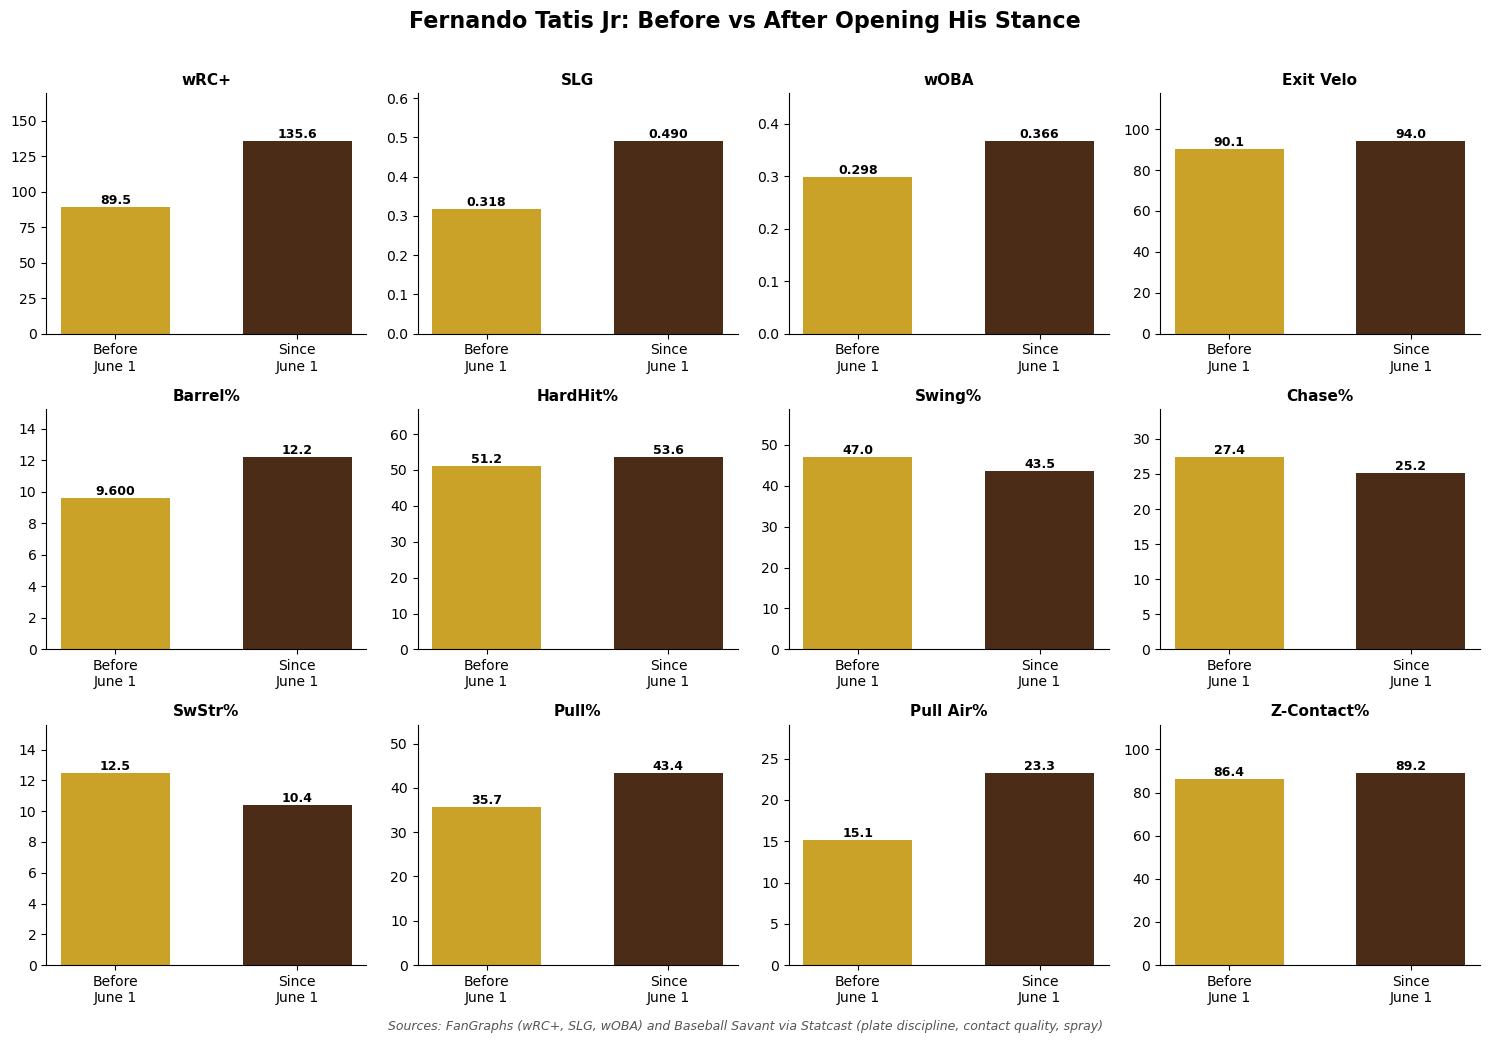

In [10]:
import matplotlib.pyplot as plt

metrics = [
    "wRC+", "SLG", "wOBA",
    "Exit Velo", "Barrel%", "HardHit%",
    "Swing%", "Chase%", "SwStr%",
    "Pull%", "Pull Air%", "Z-Contact%"
]

before_vals = [89.5, .318, .298, 90.1, 9.6, 51.2, 47.0, 27.4, 12.5, 35.7, 15.1, 86.4]
after_vals  = [135.6, .490, .366, 94.0, 12.2, 53.6, 43.5, 25.2, 10.4, 43.4, 23.3, 89.2]

gold = "#c9a227"
brown = "#4a2c17"

fig, axes = plt.subplots(3, 4, figsize=(15, 10))
fig.patch.set_facecolor("white")

for i, (m, b, a) in enumerate(zip(metrics, before_vals, after_vals)):
    ax = axes[i // 4][i % 4]
    bars = ax.bar(["Before\nJune 1", "Since\nJune 1"], [b, a], color=[gold, brown], width=0.6)
    ax.set_title(m, fontsize=11, fontweight="bold")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    for bar, val in zip(bars, [b, a]):
        label = f"{val:.3f}" if val < 10 else f"{val:.1f}"
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), label, ha="center", va="bottom", fontsize=9, fontweight="bold")
    ax.set_ylim(0, max(b, a) * 1.25)

fig.suptitle("Fernando Tatis Jr: Before vs After Opening His Stance", fontsize=16, fontweight="bold", y=1.01)
fig.text(0.5, -0.01, "Sources: FanGraphs (wRC+, SLG, wOBA) and Baseball Savant via Statcast (plate discipline, contact quality, spray)", ha="center", fontsize=9, style="italic", color="#555555")

plt.tight_layout()
plt.savefig("tatis_full_before_after.png", dpi=200, bbox_inches="tight")
plt.show()

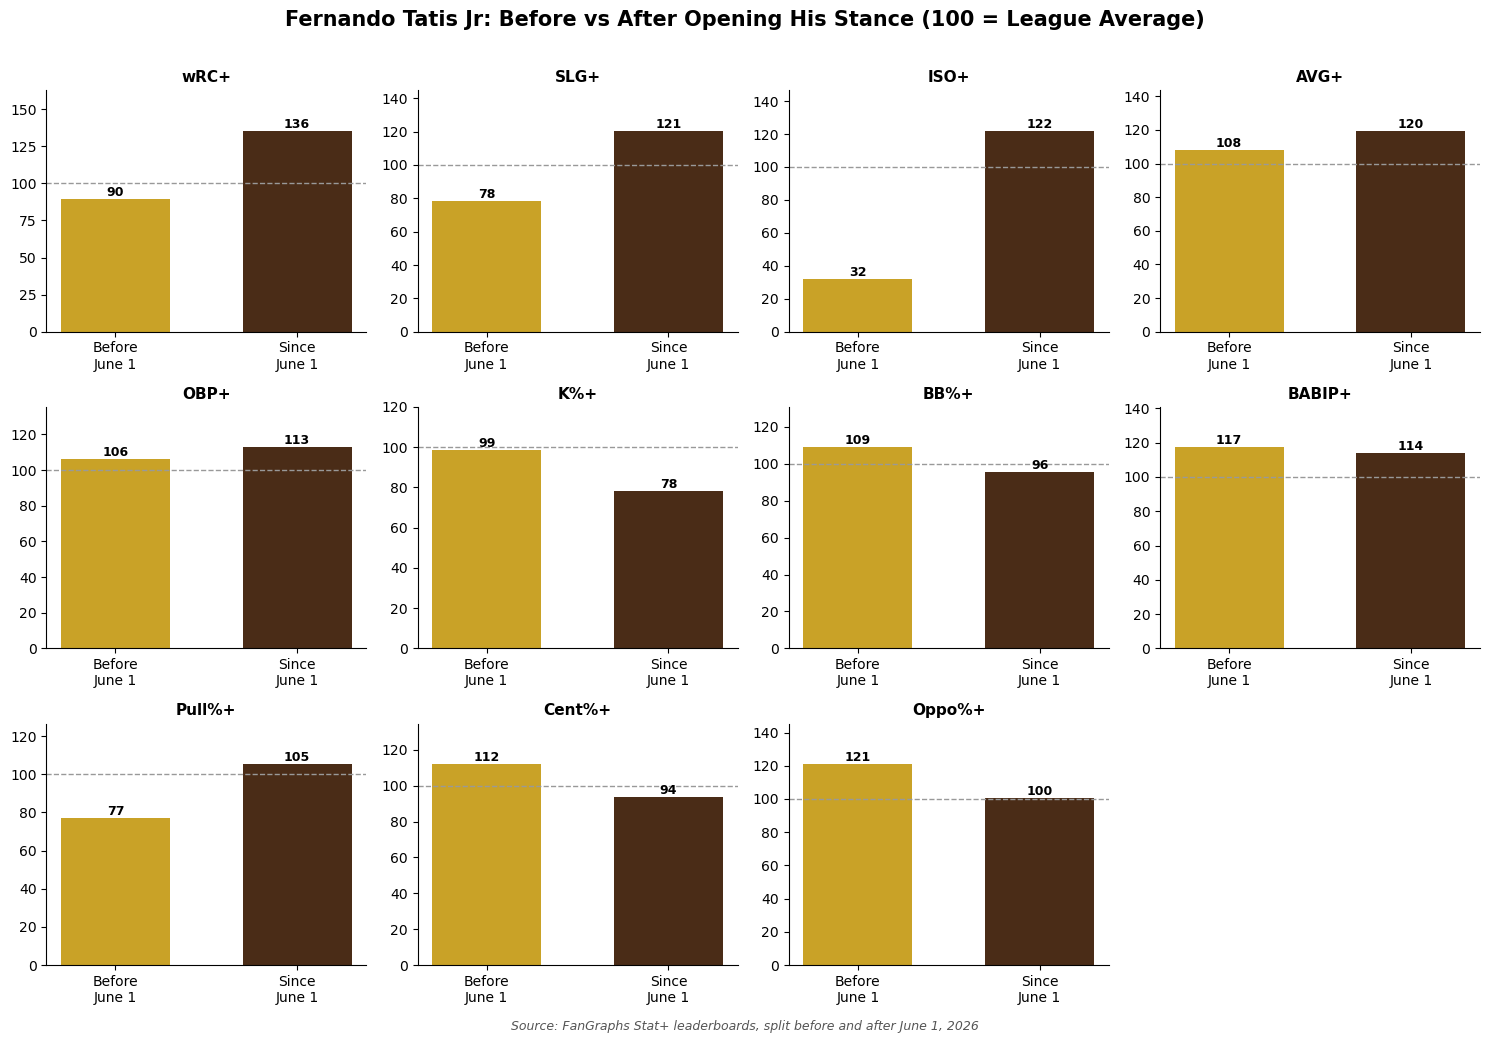

In [11]:
import matplotlib.pyplot as plt

metrics = ["wRC+", "SLG+", "ISO+", "AVG+", "OBP+", "K%+", "BB%+", "BABIP+", "Pull%+", "Cent%+", "Oppo%+"]
before_vals = [89.5, 78.3, 32.2, 108.1, 106.0, 98.8, 109.0, 117.3, 77.1, 112.1, 121.1]
after_vals  = [135.6, 120.6, 122.1, 119.6, 112.8, 78.4, 95.5, 113.9, 105.4, 93.5, 100.4]

gold = "#c9a227"
brown = "#4a2c17"

fig, axes = plt.subplots(3, 4, figsize=(15, 10))
fig.patch.set_facecolor("white")
axes_flat = axes.flatten()

for i, (m, b, a) in enumerate(zip(metrics, before_vals, after_vals)):
    ax = axes_flat[i]
    bars = ax.bar(["Before\nJune 1", "Since\nJune 1"], [b, a], color=[gold, brown], width=0.6)
    ax.set_title(m, fontsize=11, fontweight="bold")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.axhline(100, color="#999999", linewidth=1, linestyle="--")
    for bar, val in zip(bars, [b, a]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{val:.0f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
    ax.set_ylim(0, max(b, a, 100) * 1.2)

axes_flat[-1].axis("off")

fig.suptitle("Fernando Tatis Jr: Before vs After Opening His Stance (100 = League Average)", fontsize=15, fontweight="bold", y=1.01)
fig.text(0.5, -0.01, "Source: FanGraphs Stat+ leaderboards, split before and after June 1, 2026", ha="center", fontsize=9, style="italic", color="#555555")

plt.tight_layout()
plt.savefig("tatis_plus_stats.png", dpi=200, bbox_inches="tight")
plt.show()

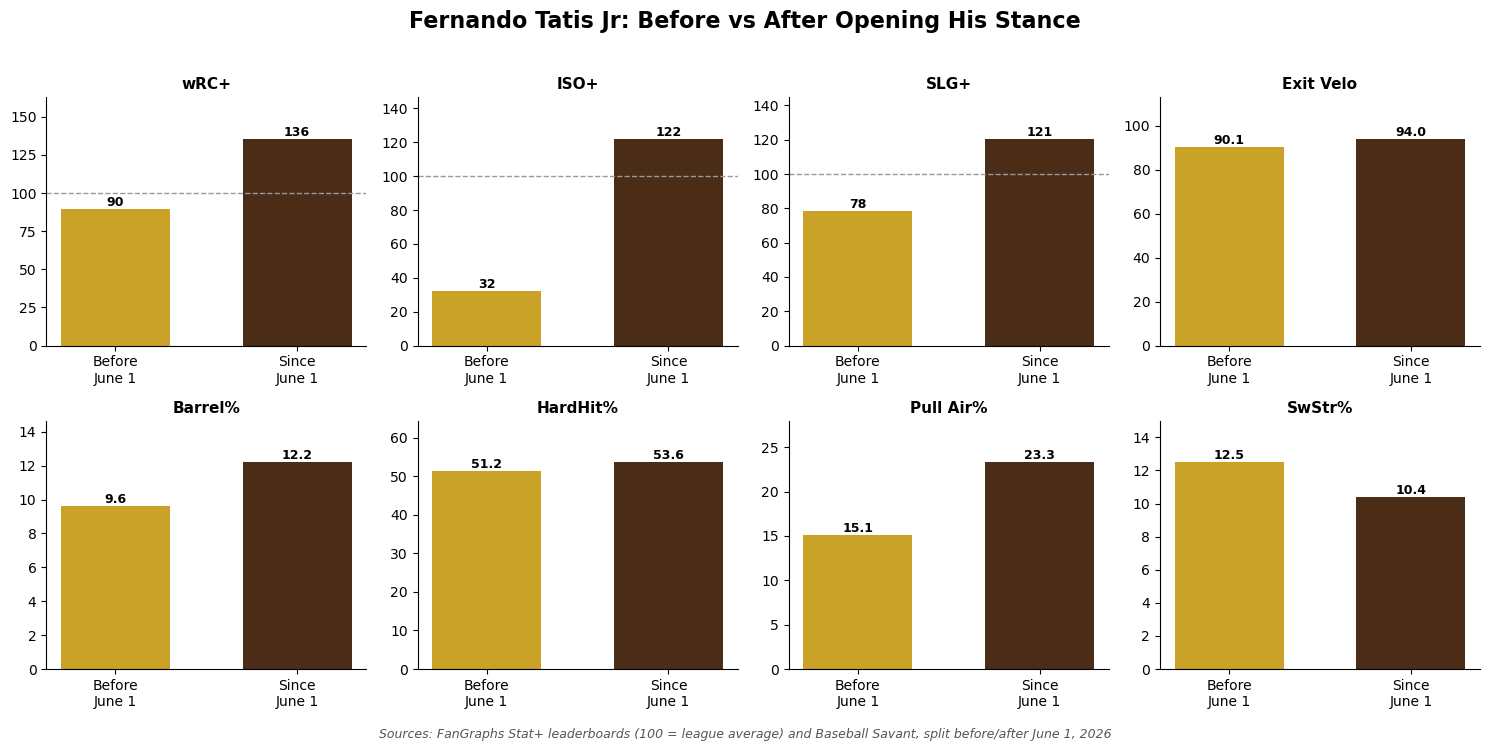

In [12]:
import matplotlib.pyplot as plt

labels = ["wRC+", "ISO+", "SLG+", "Exit Velo", "Barrel%", "HardHit%", "Pull Air%", "SwStr%"]
before_vals = [89.5, 32.2, 78.3, 90.1, 9.6, 51.2, 15.1, 12.5]
after_vals  = [135.6, 122.1, 120.6, 94.0, 12.2, 53.6, 23.3, 10.4]
is_plus = [True, True, True, False, False, False, False, False]

gold = "#c9a227"
brown = "#4a2c17"

fig, axes = plt.subplots(2, 4, figsize=(15, 7))
fig.patch.set_facecolor("white")
axes_flat = axes.flatten()

for i, (m, b, a, plus) in enumerate(zip(labels, before_vals, after_vals, is_plus)):
    ax = axes_flat[i]
    bars = ax.bar(["Before\nJune 1", "Since\nJune 1"], [b, a], color=[gold, brown], width=0.6)
    ax.set_title(m, fontsize=11, fontweight="bold")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    if plus:
        ax.axhline(100, color="#999999", linewidth=1, linestyle="--")
        fmt = "{:.0f}"
    else:
        fmt = "{:.3f}" if max(b, a) < 10 else "{:.1f}"
    for bar, val in zip(bars, [b, a]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), fmt.format(val), ha="center", va="bottom", fontsize=9, fontweight="bold")
    ax.set_ylim(0, max(b, a, 100 if plus else 0) * 1.2)

fig.suptitle("Fernando Tatis Jr: Before vs After Opening His Stance", fontsize=16, fontweight="bold", y=1.02)
fig.text(0.5, -0.02, "Sources: FanGraphs Stat+ leaderboards (100 = league average) and Baseball Savant, split before/after June 1, 2026", ha="center", fontsize=9, style="italic", color="#555555")

plt.tight_layout()
plt.savefig("tatis_elite_mix.png", dpi=200, bbox_inches="tight")
plt.show()

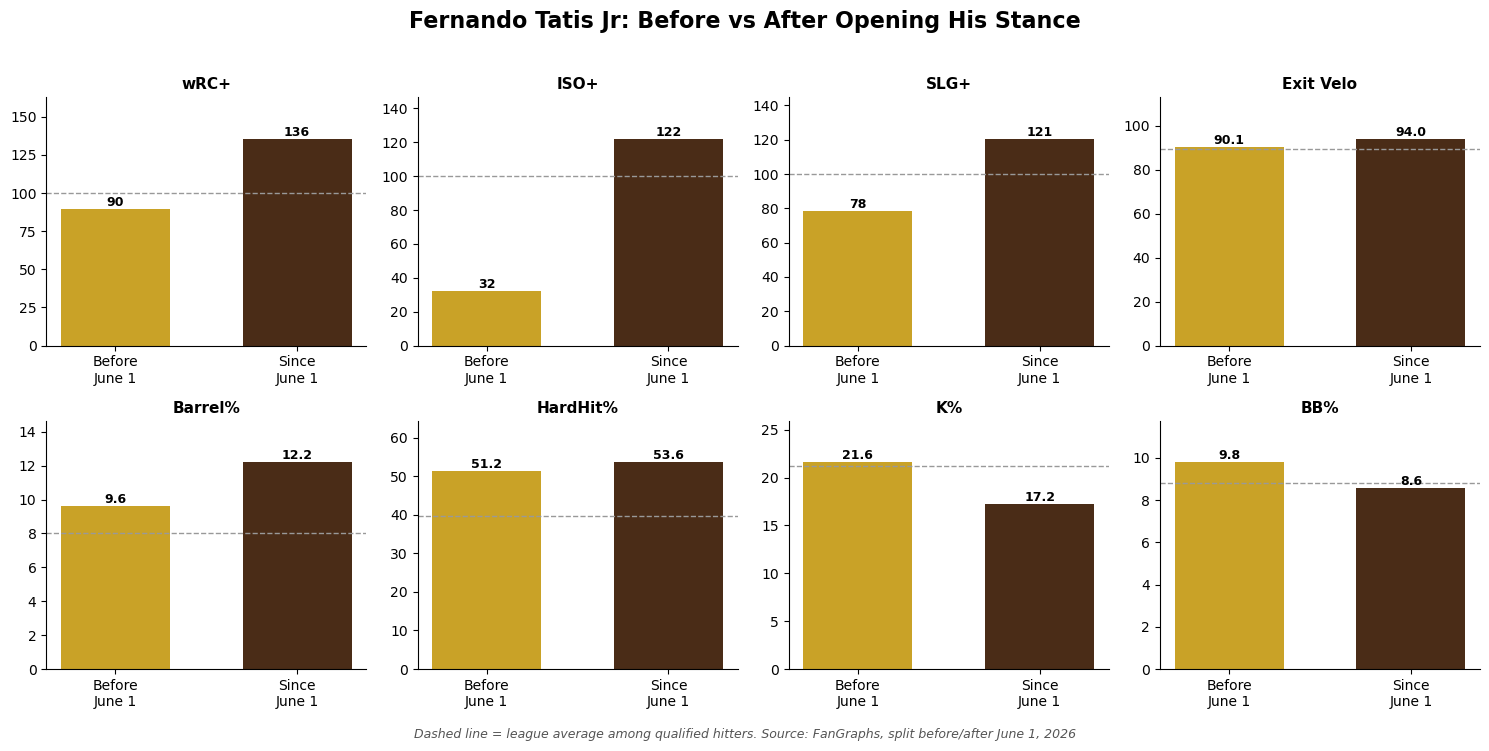

In [13]:
import matplotlib.pyplot as plt

labels = ["wRC+", "ISO+", "SLG+", "Exit Velo", "Barrel%", "HardHit%", "K%", "BB%"]
before_vals = [89.5, 32.2, 78.3, 90.1, 9.6, 51.2, 21.6, 9.8]
after_vals  = [135.6, 122.1, 120.6, 94.0, 12.2, 53.6, 17.2, 8.6]
league_avg  = [100, 100, 100, 89.1, 8.0, 39.6, 21.2, 8.8]
is_plus = [True, True, True, False, False, False, False, False]

gold = "#c9a227"
brown = "#4a2c17"

fig, axes = plt.subplots(2, 4, figsize=(15, 7))
fig.patch.set_facecolor("white")
axes_flat = axes.flatten()

for i, (m, b, a, avg, plus) in enumerate(zip(labels, before_vals, after_vals, league_avg, is_plus)):
    ax = axes_flat[i]
    bars = ax.bar(["Before\nJune 1", "Since\nJune 1"], [b, a], color=[gold, brown], width=0.6)
    ax.set_title(m, fontsize=11, fontweight="bold")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.axhline(avg, color="#999999", linewidth=1, linestyle="--")
    fmt = "{:.0f}" if plus else ("{:.1f}" if max(b, a) > 5 else "{:.3f}")
    for bar, val in zip(bars, [b, a]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), fmt.format(val), ha="center", va="bottom", fontsize=9, fontweight="bold")
    ax.set_ylim(0, max(b, a, avg) * 1.2)

fig.suptitle("Fernando Tatis Jr: Before vs After Opening His Stance", fontsize=16, fontweight="bold", y=1.02)
fig.text(0.5, -0.02, "Dashed line = league average among qualified hitters. Source: FanGraphs, split before/after June 1, 2026", ha="center", fontsize=9, style="italic", color="#555555")

plt.tight_layout()
plt.savefig("tatis_elite_mix.png", dpi=200, bbox_inches="tight")
plt.show()

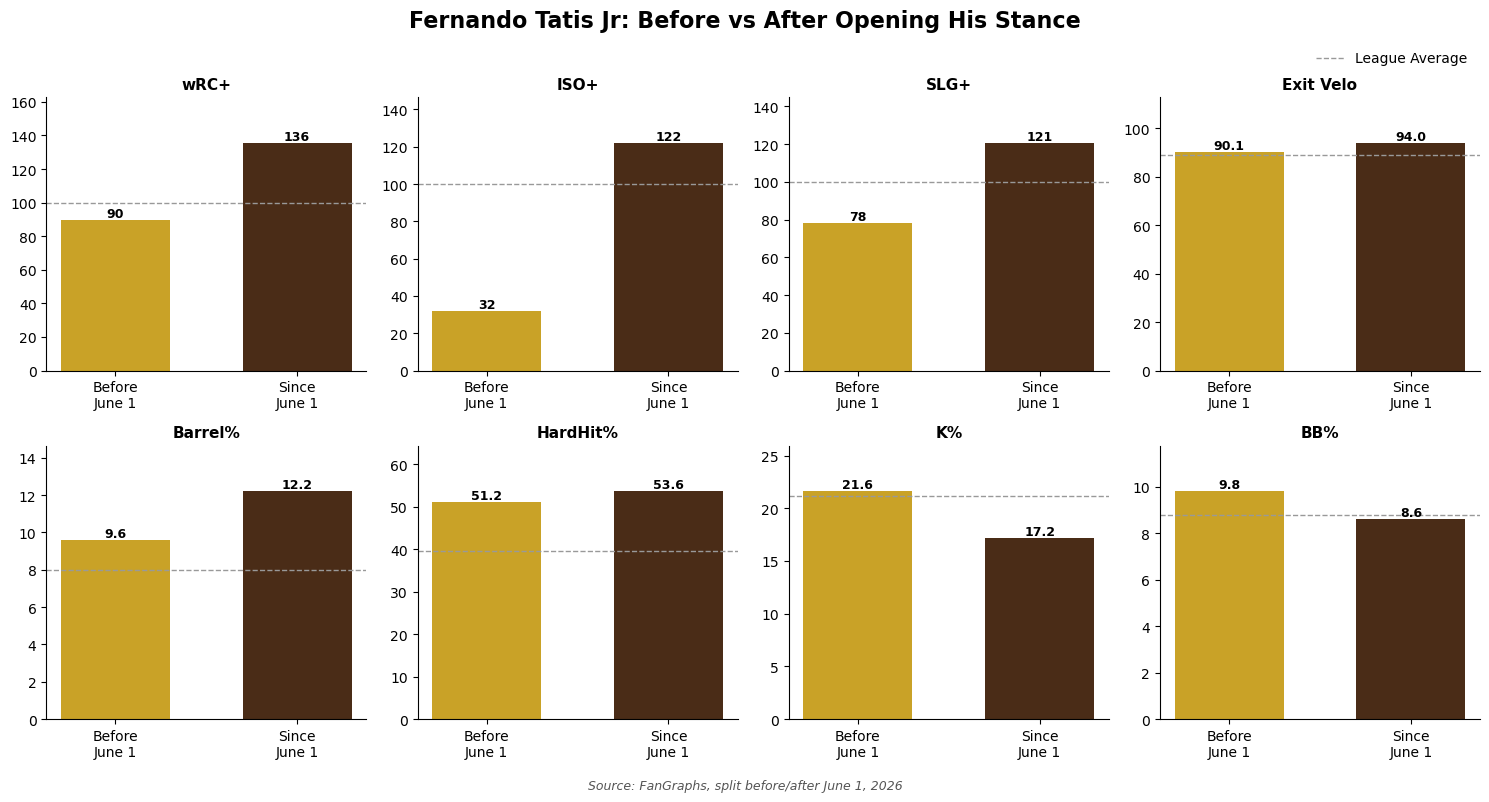

In [14]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

labels = ["wRC+", "ISO+", "SLG+", "Exit Velo", "Barrel%", "HardHit%", "K%", "BB%"]
before_vals = [89.5, 32.2, 78.3, 90.1, 9.6, 51.2, 21.6, 9.8]
after_vals  = [135.6, 122.1, 120.6, 94.0, 12.2, 53.6, 17.2, 8.6]
league_avg  = [100, 100, 100, 89.1, 8.0, 39.6, 21.2, 8.8]
is_plus = [True, True, True, False, False, False, False, False]

gold = "#c9a227"
brown = "#4a2c17"
gray = "#999999"

fig, axes = plt.subplots(2, 4, figsize=(15, 7.5))
fig.patch.set_facecolor("white")
axes_flat = axes.flatten()

for i, (m, b, a, avg, plus) in enumerate(zip(labels, before_vals, after_vals, league_avg, is_plus)):
    ax = axes_flat[i]
    bars = ax.bar(["Before\nJune 1", "Since\nJune 1"], [b, a], color=[gold, brown], width=0.6)
    ax.set_title(m, fontsize=11, fontweight="bold")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.axhline(avg, color=gray, linewidth=1, linestyle="--")
    fmt = "{:.0f}" if plus else ("{:.1f}" if max(b, a) > 5 else "{:.3f}")
    for bar, val in zip(bars, [b, a]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), fmt.format(val), ha="center", va="bottom", fontsize=9, fontweight="bold")
    ax.set_ylim(0, max(b, a, avg) * 1.2)

legend_elements = [
    Line2D([0], [0], color=gray, linewidth=1, linestyle="--", label="League Average"),
]
fig.legend(handles=legend_elements, loc="upper right", bbox_to_anchor=(0.99, 0.98), fontsize=10, frameon=False)

fig.suptitle("Fernando Tatis Jr: Before vs After Opening His Stance", fontsize=16, fontweight="bold", y=1.02)
fig.text(0.5, -0.02, "Source: FanGraphs, split before/after June 1, 2026", ha="center", fontsize=9, style="italic", color="#555555")

plt.tight_layout()
plt.savefig("tatis_elite_mix.png", dpi=200, bbox_inches="tight")
plt.show()